# Crater degradation-state pipeline — evaluation against Julie's labeled set

End-to-end: **Julie's labeled PNGs → MAE encoder → latents → KMeans → align clusters to classes → metrics.**

Layout this notebook expects:
```
<repo_root>/
  src/eval/        ← harness code (contract, align, metrics, pipeline, ...)
  eval/            ← THIS notebook lives here
  configs/         ← erosion4.yaml, global_scaling.json
  data/raw/craters_for_danny    ← Julie's PNGs, checkpoint
```

Set `SYNTHETIC = True` to run with fabricated data (no GPU/checkpoint needed).

## 0 · Setup — anchor to repo root, wire imports

In [1]:
import sys, os
from pathlib import Path

# Find repo root: walk up until we see a `src/eval` dir. Works from eval/ or root.
def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "eval").is_dir():
            return p
    raise RuntimeError("could not locate repo root (no src/eval found above CWD)")

ROOT = _find_root(Path.cwd())
os.chdir(ROOT)                       # all relative paths below are repo-root-relative
sys.path.insert(0, str(ROOT / "src"))   # so `import eval.*` -> src/eval/*
sys.path.insert(0, str(ROOT))           # so `import src.models.*` resolves
print("repo root:", ROOT)

%matplotlib inline
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
from eval.contract import LabelScheme, load_predictions
from eval.align import align, apply_mapping
from eval import metrics as M
from eval import pipeline as P
pd.set_option("display.precision", 3)
SYNTHETIC = False       # <<< False once checkpoint + imgs_dir are real

repo root: /home/kinreich/autoencoder_project


## 1 · Config + labels from Julie's PNG folder
Labels are read from filenames `<crater_id>_<state>.png` (state 1–4 → ordinal
0–3, 0 = freshest). Paths in the config are repo-root-relative.

In [2]:
CONFIG = "configs/erosion4.yaml"
cfg = yaml.safe_load(open(CONFIG))
scheme = LabelScheme(names=cfg["class_names"]); K = scheme.n_classes
print("classes:", scheme.names, "| n_clusters:", cfg["n_clusters"])

if SYNTHETIC and not os.path.isdir(cfg["imgs_dir"]):
    rng = np.random.default_rng(1); N = 200
    labels = pd.DataFrame({
        "crater_id": [f"c{i:04d}_{rng.integers(1,5)}" for i in range(N)],
        "true_label": rng.integers(0, K, N),
        "filename": [f"c{i:04d}.png" for i in range(N)],
    })
else:
    labels = P.labels_from_png_dir(cfg["imgs_dir"])

print(f"{len(labels)} labeled craters")
print(labels["true_label"].value_counts().sort_index()
      .rename(index=dict(enumerate(scheme.names))))
labels.head()

classes: ['Semi-New', 'Semi-Old', 'Old'] | n_clusters: 3
150 labeled craters
true_label
Semi-New     12
Semi-Old     35
Old         103
Name: count, dtype: int64


,crater_id,true_label,filename
0,0_3,1,0_3.png
1,100_4,2,100_4.png
2,101_3,1,101_3.png
3,102_4,2,102_4.png
4,103_4,2,103_4.png


## 2 · Embed → cluster
`P.embed` runs the real MAE encoder (or fabricates latents if `SYNTHETIC`).
`P.kmeans_cluster` returns per-centroid distances for the calibration metrics.

In [3]:
latents = P.embed(labels, cfg, synthetic=SYNTHETIC)
clusters, dists, km = P.kmeans_cluster(latents, cfg)
pred = P.build_predictions(labels, latents, clusters, dists)
os.makedirs("data", exist_ok=True)
pred.to_csv("data/predictions.csv", index=False); np.save("data/latents.npy", latents)
print(f"latents {latents.shape} | {pred['cluster'].nunique()} clusters")
pred.head()

/home/kinreich/autoencoder_project/src/models/dinov2/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/kinreich/autoencoder_project/src/models/dinov2/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/kinreich/autoencoder_project/src/models/dinov2/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


latents (150, 768) | 3 clusters


,crater_id,true_label,filename,cluster,dist_0,dist_1,dist_2
0,0_3,1,0_3.png,0,6.203,8.589,7.125
1,100_4,2,100_4.png,1,8.607,7.144,8.354
2,101_3,1,101_3.png,1,10.607,6.431,7.754
3,102_4,2,102_4.png,2,6.547,7.614,6.288
4,103_4,2,103_4.png,0,4.322,8.644,5.666


## 3 · Align clusters → classes
Over-clustering switches to majority-vote and warns.

In [4]:
df = load_predictions("data/predictions.csv", scheme)
mapping, info = align(df, K); df = apply_mapping(df, mapping)
print("mode:", info["mode"], "| purity:", round(info["purity"],3),
      "| n_clusters:", info["n_clusters"])
print("cluster -> class:", mapping)

mode: hungarian_1to1 | purity: 0.453 | n_clusters: 3
cluster -> class: {0: 2, 1: 0, 2: 1}


## 4 · Confusion matrix

In [6]:
cm = M.confusion(df, K)
fig, ax = plt.subplots(figsize=(5,4.2)); im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(scheme.names, rotation=45, ha="right"); ax.set_yticklabels(scheme.names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(K):
    for j in range(K):
        ax.text(j,i,cm[i,j],ha="center",va="center",
                color="white" if cm[i,j]>cm.max()/2 else "black")
ax.set_title("Confusion (banding near diagonal = ordinal signal)")
plt.colorbar(im); plt.tight_layout(); plt.show()

## 4b · Sample craters — where true and predicted class agreed vs. disagreed
Random crater images from each group, titled `true → predicted`. Useful for
eyeballing *what kind* of craters the model confuses, not just how many.

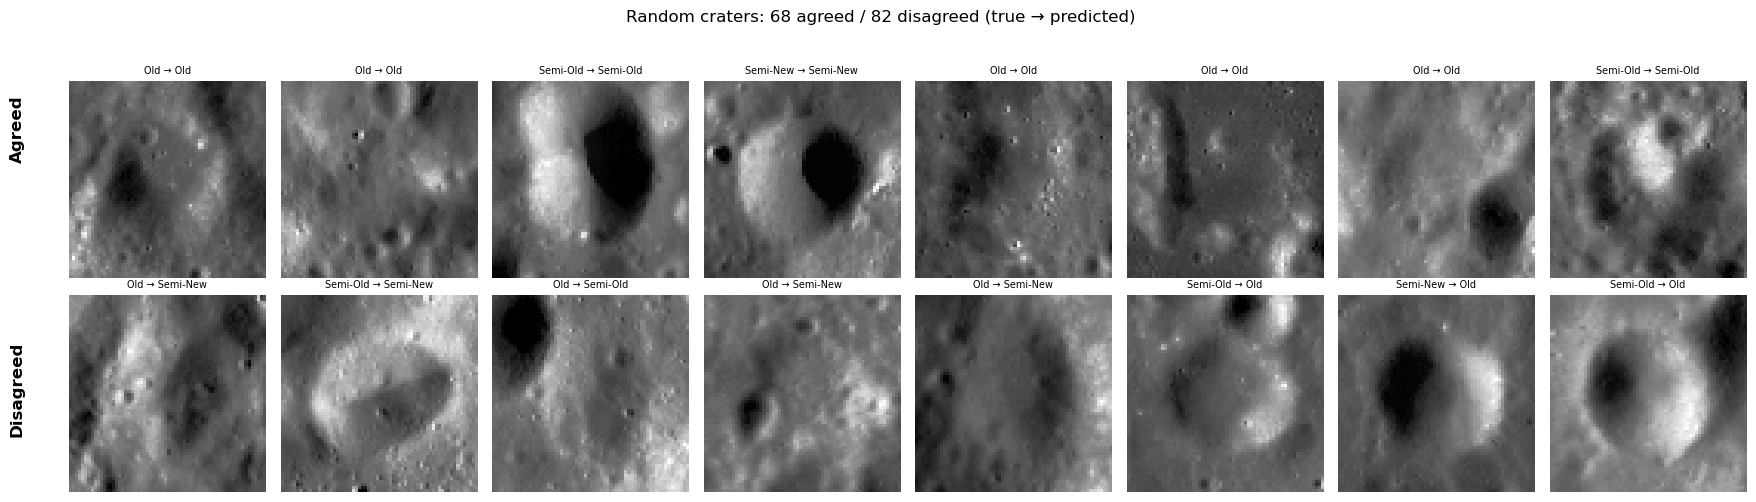

In [7]:
import cv2

N_PER_GROUP = 8

agree = df[df["true_label"] == df["pred_label"]]
disagree = df[df["true_label"] != df["pred_label"]]

def sample_rows(sub, n, seed=0):
    n = min(n, len(sub))
    return sub.sample(n=n, random_state=seed) if n > 0 else sub

agree_sample = sample_rows(agree, N_PER_GROUP)
disagree_sample = sample_rows(disagree, N_PER_GROUP)

def load_gray(fname):
    img = cv2.imread(os.path.join(cfg["imgs_dir"], fname))
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img is not None else None

fig, axes = plt.subplots(2, N_PER_GROUP, figsize=(2.2 * N_PER_GROUP, 5.2))
for row, (sample, rtitle) in enumerate([(agree_sample, "Agreed"), (disagree_sample, "Disagreed")]):
    for col in range(N_PER_GROUP):
        ax = axes[row, col]
        ax.axis("off")
        if col >= len(sample):
            continue
        r = sample.iloc[col]
        img = load_gray(r["filename"])
        if img is None:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", fontsize=8)
            continue
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{scheme.names[r['true_label']]} → {scheme.names[r['pred_label']]}", fontsize=7)
    fig.text(0.005, 0.75 - row * 0.5, rtitle, rotation=90, va="center", fontsize=12, fontweight="bold")

plt.suptitle(f"Random craters: {len(agree)} agreed / {len(disagree)} disagreed (true → predicted)")
plt.tight_layout(rect=[0.03, 0, 1, 0.95])
fig

## 5 · Per-class precision / recall / F1

In [8]:
pc = M.per_class(df, K); pc.index = scheme.names
display(pc.round(3))
weak = pc["recall"].idxmin()
print(f"weakest class by recall: '{weak}' ({pc.loc[weak,'recall']:.2f})")

,precision,recall,f1,support
Semi-New,0.158,0.250,0.194,12
Semi-Old,0.229,0.314,0.265,35
Old,0.651,0.524,0.581,103


weakest class by recall: 'Semi-New' (0.25)


## 6 · Ordinal metrics

In [9]:
print(f"quadratic weighted kappa: {M.quadratic_weighted_kappa(df, K):.3f}")
print(f"ordinal MAE:              {M.ordinal_mae(df):.3f}")

quadratic weighted kappa: -0.041
ordinal MAE:              0.687


## 7 · Calibration — reliability + ECE

In [10]:
cal = M.ece(df, mapping, K)
if cal is None:
    print("no dist_* columns -> skipped")
else:
    b = cal["bins"].dropna(subset=["acc"])
    fig, ax = plt.subplots(figsize=(4.6,4.6))
    ax.plot([0,1],[0,1],"--",color="gray",label="perfect")
    ax.plot(b["conf"], b["acc"], "o-", label="model")
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    ax.set_title(f"Reliability (ECE = {cal['ece']:.3f})"); ax.legend()
    plt.tight_layout(); plt.show()

## 8 · Separation in latent space

In [11]:
sep = M.separation(latents, df, info)
for k_, v in sep.items():
    print(f"{k_:20s} {v:.3f}" if v is not None else f"{k_:20s} n/a")

purity               0.453
silhouette_true      -0.029
silhouette_cluster   0.108


## 8b · Latent space in PCA space, colored by true class
2D PCA projection of the raw latents — one point per crater, colored by
ground-truth label. Shows how spread out/separated the classes actually are
in the encoder's latent space, independent of how KMeans happened to cluster them.

/tmp/ipykernel_965664/1536779395.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


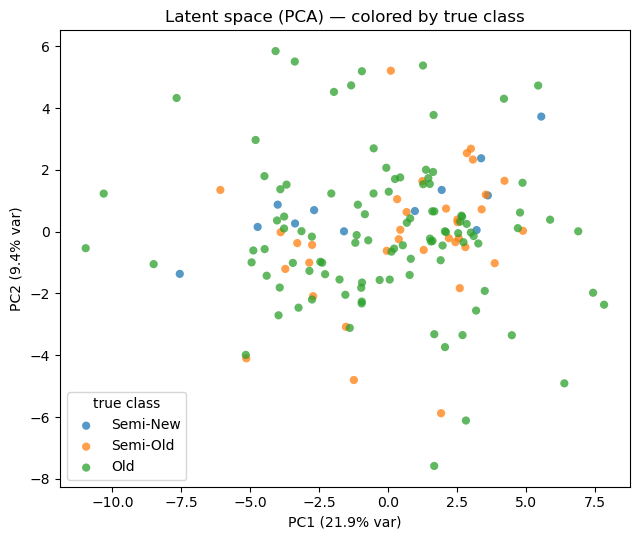

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(latents)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cmap = plt.cm.get_cmap("tab10")
for v in sorted(df["true_label"].unique()):
    mask = (df["true_label"] == v).to_numpy()
    ax.scatter(coords[mask, 0], coords[mask, 1], s=35, alpha=0.75,
              color=cmap(v % 10), label=scheme.names[v], edgecolors="none")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
ax.set_title("Latent space (PCA) — colored by true class")
ax.legend(title="true class")
plt.tight_layout()
fig

## 9 · Bootstrap 95% CIs

In [13]:
rows = []
for name, fn in [("accuracy",M.acc_fn),("macro_f1",M.macrof1_fn),
                 ("quad_weighted_kappa",M.qwk_fn),("ordinal_mae",M.ordmae_fn)]:
    r = M.bootstrap_ci(df, K, fn, n_boot=2000)
    rows.append({"metric":name,"point":r["point"],"ci_lo":r["lo"],"ci_hi":r["hi"]})
summary = pd.DataFrame(rows).set_index("metric"); display(summary.round(3))

,point,ci_lo,ci_hi
metric,,,
accuracy,0.453,0.367,0.533
macro_f1,0.346,0.260,0.431
quad_weighted_kappa,-0.041,-0.198,0.128
ordinal_mae,0.687,0.573,0.807


## 10 · Save report
Or run the CLI from repo root:
```bash
PYTHONPATH=src python -m eval.evaluate --predictions data/predictions.csv \
    --config configs/erosion4.yaml --latents data/latents.npy --out runs/baseline
```

In [10]:
os.makedirs("runs/notebook", exist_ok=True)
summary.to_csv("runs/notebook/summary.csv")
pd.DataFrame(cm,index=scheme.names,columns=scheme.names).to_csv("runs/notebook/confusion.csv")
pc.to_csv("runs/notebook/per_class.csv")
print("saved -> runs/notebook/")

saved -> runs/notebook/


---
### Notes
- The setup cell `os.chdir(ROOT)` once, so every later path is repo-root-relative
  regardless of where you launched Jupyter.
- Eval preprocessing matches the encoder's training scaling (global percentile);
  see `configs/erosion4.yaml` and `src/eval/pipeline.py`.

In [14]:
import cv2
img = cv2.cvtColor(cv2.imread("data/raw/craters_for_danny/0_3.png"), cv2.COLOR_BGR2GRAY)


plt.imshow(img, cmap = "gray")
plt.show()